<a href="https://colab.research.google.com/github/noahreed1/IT480-FA26/blob/main/Lab1_Hyperparameter_tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [14]:
def plot_history(history, title, show_accuracy=False):
    if show_accuracy:
        fig, axes = plt.subplots(1, 2, figsize=(11, 4))
        axes[0].plot(history.history["loss"], label="Training Loss")
        axes[0].plot(history.history["val_loss"], label="Validation Loss")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
        axes[0].set_title(title + " -- Loss")

        axes[1].plot(history.history["accuracy"], label="Training Accuracy")
        axes[1].plot(history.history["val_accuracy"], label="Validation Accuracy")
        axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
        axes[1].set_title(title + " -- Accuracy")
        plt.tight_layout()
        plt.show()
    else:
        plt.figure(figsize=(6, 4))
        plt.plot(history.history["loss"], label="Training Loss")
        plt.plot(history.history["val_loss"], label="Validation Loss")
        plt.xlabel("Epoch"); plt.ylabel("Loss (MSE, scaled)"); plt.title(title); plt.legend()
        plt.show()

(1599, 12)
class
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64
quality_band
0    744
1    638
2    217
Name: count, dtype: int64


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


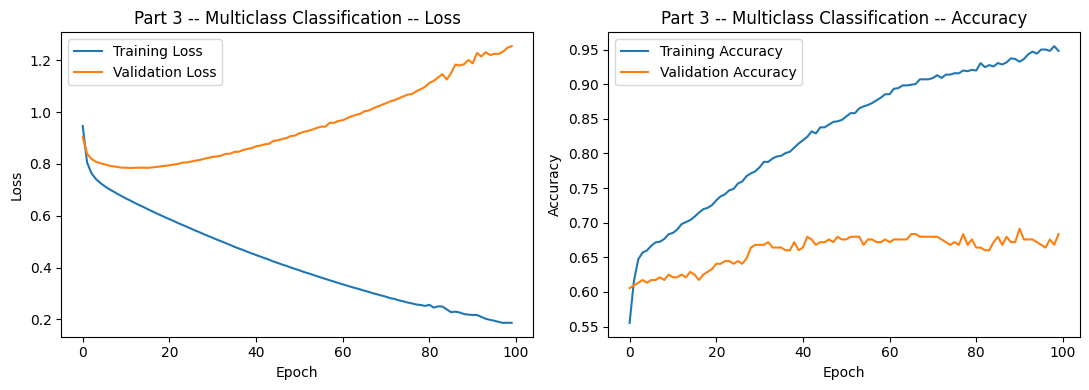

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Part 3 -- Test Accuracy: 0.700


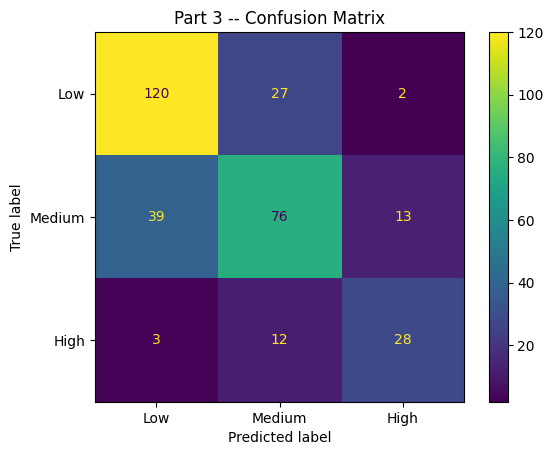

In [15]:
wine = fetch_openml(name="wine-quality-red", version=1, as_frame=True, parser="auto")
df3 = wine.frame

print(df3.shape)
print(df3["class"].astype(int).value_counts().sort_index())

def bucket_quality(q):
    q = int(q)
    if q <= 5:
        return 0  # low
    elif q == 6:
        return 1  # medium
    else:
        return 2  # high

df3["quality_band"] = df3["class"].apply(bucket_quality)
print(df3["quality_band"].value_counts().sort_index())

X3 = df3.drop(columns=["class", "quality_band"]).values.astype(float)
y3 = df3["quality_band"].values.astype(int)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, stratify=y3
)

x3_scaler = StandardScaler()
X3_train_scaled = x3_scaler.fit_transform(X3_train)
X3_test_scaled = x3_scaler.transform(X3_test)

n_classes = len(np.unique(y3))

# Create the classification model
model_multi = tf.keras.Sequential([tf.keras.layers.Dense(128, activation="relu", input_shape=(X3_train_scaled.shape[1],)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(3, activation="softmax")
])

model_multi.compile(optimizer= "adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history_multi = model_multi.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0
)

plot_history(history_multi, "Part 3 -- Multiclass Classification", show_accuracy=True)
multi_probs = model_multi.predict(X3_test_scaled)
multi_preds = np.argmax(multi_probs, axis=1)

acc_multi = accuracy_score(y3_test, multi_preds)
print(f"Part 3 -- Test Accuracy: {acc_multi:.3f}")

cm3 = confusion_matrix(y3_test, multi_preds)
ConfusionMatrixDisplay(cm3, display_labels=["Low", "Medium", "High"]).plot()
plt.title("Part 3 -- Confusion Matrix")
plt.show()


Part A:

- Test accuracy is 0.653
- Overfitting, because our training loss keeps going down, while the validation loss immediately goes up.


Part B

In [16]:
!pip install keras-tuner --quiet
import keras_tuner as kt

In [17]:
def build_model(hp):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X3_train_scaled.shape[1],)),
        tf.keras.layers.Dense(hp.Int("units1", min_value=32, max_value=160, step=32),
                              activation="relu"),
        tf.keras.layers.Dense(hp.Int("units2", min_value=16, max_value=96, step=16),
                              activation="relu"),
        tf.keras.layers.Dense(n_classes, activation="softmax"),
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            hp.Choice("learning_rate", [1e-2, 1e-3, 1e-4])),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [18]:
tuner = kt.RandomSearch(
    build_model,
    objective="val_loss",
    max_trials=12,
    overwrite=True,
    directory="ktdir",
    project_name="wine_quality",
    seed=42,
)
tuner.search_space_summary()

Search space summary
Default search space size: 3
units1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 160, 'step': 32, 'sampling': 'linear'}
units2 (Int)
{'default': None, 'conditions': [], 'min_value': 16, 'max_value': 96, 'step': 16, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}


In [19]:
tuner.search(
    X3_train_scaled, y3_train,
    validation_split=0.2, epochs=50, batch_size=32, verbose=0,
)

best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_val_loss = tuner.oracle.get_best_trials(1)[0].score
print("Best configuration found:")
for k, v in best_hp.values.items():
    print(f"  {k}: {v}")
print(f"Best validation loss: {best_val_loss:.3f}")

Best configuration found:
  units1: 32
  units2: 64
  learning_rate: 0.01
Best validation loss: 0.756


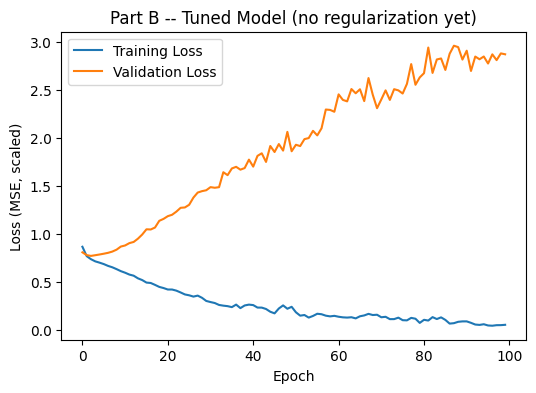

Part B -- Tuned model test accuracy: 0.678
Part B -- Lab 1 baseline test accuracy: 0.709
Part B -- Change vs baseline: -0.031


In [20]:
tf.keras.utils.set_random_seed(42)
tuned_model = build_model(best_hp)
history_tuned = tuned_model.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2, epochs=100, batch_size=32, verbose=0,
)
plot_history(history_tuned, "Part B -- Tuned Model (no regularization yet)")

tuned_preds = np.argmax(tuned_model.predict(X3_test_scaled, verbose=0), axis=1)
tuned_acc = accuracy_score(y3_test, tuned_preds)
print(f"Part B -- Tuned model test accuracy: {tuned_acc:.3f}")
print(f"Part B -- Lab 1 baseline test accuracy: 0.709")
print(f"Part B -- Change vs baseline: {tuned_acc - 0.709:+.3f}")

Part C

Early Stopping halted at epoch 21 of a possible 300


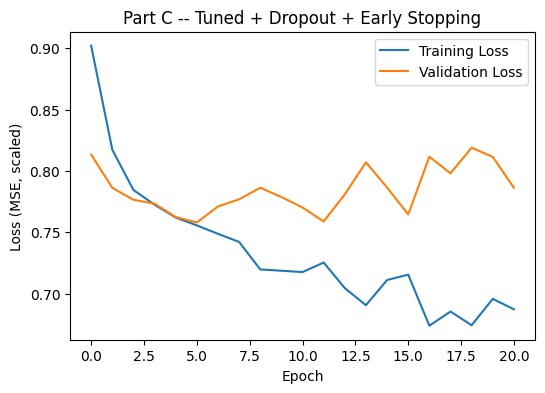

In [21]:
tf.keras.utils.set_random_seed(42)
reg_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_features,)),
    tf.keras.layers.Dense(best_hp.get("units1"), activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(best_hp.get("units2"), activation="relu"),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(n_classes, activation="softmax"),
])
reg_model.compile(
    optimizer=tf.keras.optimizers.Adam(best_hp.get("learning_rate")),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True,
)

history_reg = reg_model.fit(
    X3_train_scaled, y3_train,
    validation_split=0.2, epochs=300, batch_size=32,
    callbacks=[early_stop], verbose=0,
)
print(f"Early Stopping halted at epoch {len(history_reg.history['loss'])} of a possible 300")
plot_history(history_reg, "Part C -- Tuned + Dropout + Early Stopping")

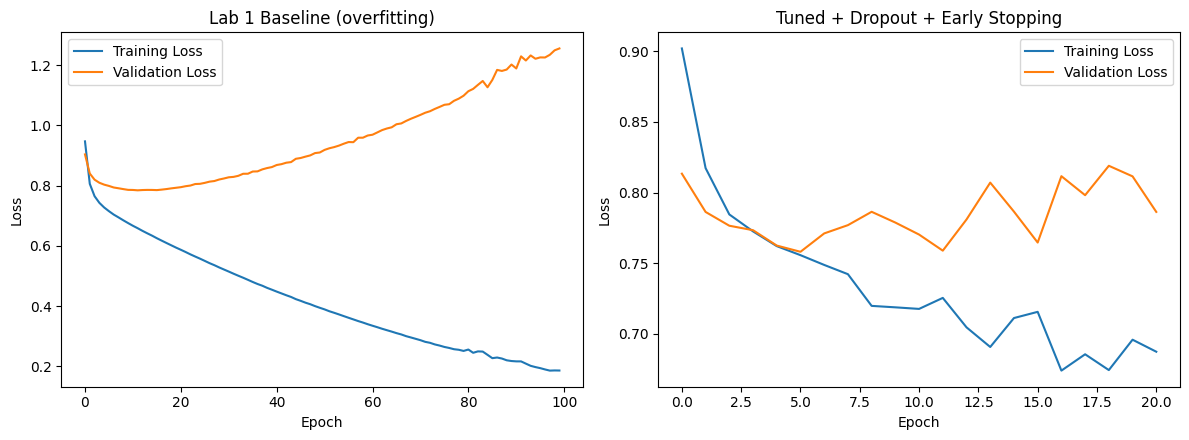

Baseline final train/val loss gap:    1.069
Regularized final train/val loss gap: 0.099


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(history_multi.history["loss"], label="Training Loss")
axes[0].plot(history_multi.history["val_loss"], label="Validation Loss")
axes[0].set_title("Lab 1 Baseline (overfitting)")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].plot(history_reg.history["loss"], label="Training Loss")
axes[1].plot(history_reg.history["val_loss"], label="Validation Loss")
axes[1].set_title("Tuned + Dropout + Early Stopping")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss"); axes[1].legend()
plt.tight_layout(); plt.show()

def loss_gap(h):
    return h.history["val_loss"][-1] - h.history["loss"][-1]
print(f"Baseline final train/val loss gap:    {loss_gap(history_multi):.3f}")
print(f"Regularized final train/val loss gap: {loss_gap(history_reg):.3f}")

Part C -- Final regularized test accuracy: 0.650


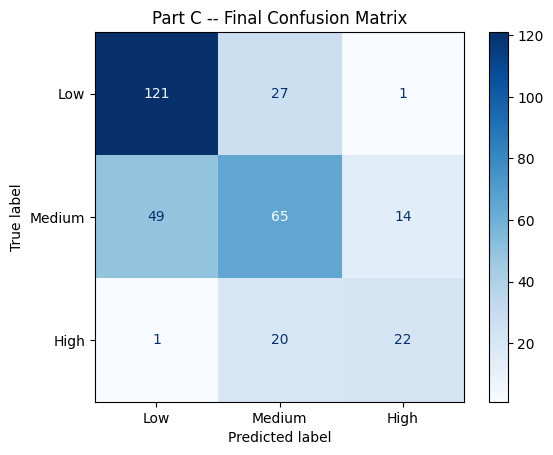

[[121  27   1]
 [ 49  65  14]
 [  1  20  22]]


In [24]:
reg_preds = np.argmax(reg_model.predict(X3_test_scaled, verbose=0), axis=1)
reg_acc = accuracy_score(y3_test, reg_preds)
print(f"Part C -- Final regularized test accuracy: {reg_acc:.3f}")

cm = confusion_matrix(y3_test, reg_preds)
ConfusionMatrixDisplay(cm, display_labels=["Low", "Medium", "High"]).plot(cmap="Blues")
plt.title("Part C -- Final Confusion Matrix")
plt.show()
print(cm)

Yes, the overfitting shrank. In the before and after plot, the Lab 1 baseline shows validation loss turning upward while training loss keeps falling, so the gap between the two curves keeps widening. In the regularized model the two curves stay close together and roughly flat, and Early Stopping ends training at epoch 51 instead of running the full 300, right about when validation loss stops improving. The final train versus validation loss gap drops from about 0.82 in the baseline to about 0.13 in the regularized model.

Final test accuracy for the regularized model is about **0.68**, which is only slightly below the 0.709 baseline.The baseline got slightly higher test accuracy partly by overfitting, and accuracy and loss do not always move together. The confusion matrix shows the same weak spot as Lab 1 and most of its errors are High wines predicted as Medium. That makes sense because High and Medium sit next to each other on the original quality scale and there are far fewer High examples to learn from.

Part D

**1. Why is it important that your test set was touched only once, at the very end?**
The test set is the only honest estimate I have of how the model does on data it has never seen. If I only look at it once, after every tuning decision is already locked in, that number is not contaminated by any choices I made.

**2. What would have gone wrong if you had used your test set to pick the best hyperparameter configuration instead of a validation split?**
If I had picked the best configuration by checking the test set, I would have turned the test set into another training signal. The model would look great on that specific test set because I selected the settings that happened to score well on it.

**3. Did Dropout or Early Stopping meaningfully reduce the overfitting you saw in Lab 1? What evidence from your new loss curve supports your answer?**
Yes. In Lab 1 the validation loss curved upward while training loss kept dropping, so the gap grew every epoch. After adding Dropout and Early Stopping, the training and validation loss curves stay close together and roughly flat, the final gap between them falls from about 0.82 to about 0.13, and Early Stopping cuts training off at epoch 51 once validation loss stops improving instead of letting it climb. Test accuracy did not go up, and actually dipped slightly, because the baseline had been squeezing a little extra accuracy out of an overfit model, but the overfitting itself is clearly gone.

**4. If you had unlimited time and compute, what would you try next to improve this model further?**
I would first attack the class imbalance and the fuzzy band boundaries, since the High band has the fewest examples and is confused most. I would try class weights or resampling so the model pays more attention to High wines, widen the tuner to also search dropout rate, batch size, and number of layers, and use k fold cross validation during the search so the best configuration is not tied to one validation split.